## Principal Component Analysis

In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

print(X_train.shape) # m x n
print(X_test.shape)

((60000, 784), (10000, 784))

In [2]:
from sklearn.decomposition import PCA # singular value decomposition
import numpy as np

pca = PCA()
pca.fit(X_train) # automatically takes care of centering the data, X_centered = X - X.mean(axis=0)
cumsum = np.cumsum(pca.explained_variance_ratio_)
d = np.argmax(cumsum >= 0.95) + 1 # d equals 154
d

np.int64(154)

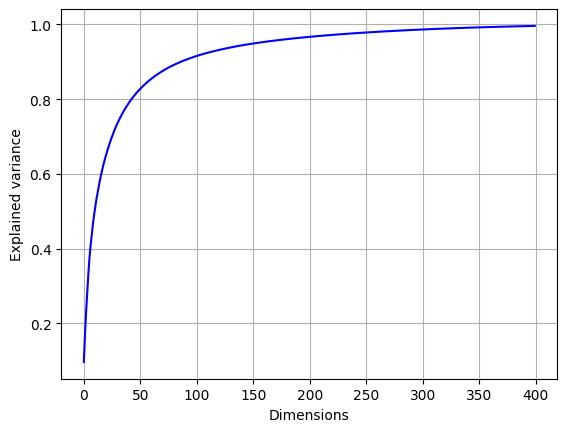

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([i for i in range(400)], cumsum[:400], color="blue")
ax.set_xlabel("Dimensions")
ax.set_ylabel("Explained variance")
plt.grid(True)
plt.show()

In [3]:
pca = PCA(n_components=0.95)

print(pca.fit_transform(X_train).shape) # m x d

(60000, 154)


In [4]:
# Estos son los importantes

print(pca.components_.shape) # d x n
print(pca.n_components_)
print(pca.explained_variance_ratio_)

(154, 784)
154
[0.09704664 0.07095924 0.06169089 0.05389419 0.04868797 0.04312231
 0.0327193  0.02883895 0.02762029 0.02357001 0.0210919  0.02022991
 0.01715818 0.01692111 0.01578641 0.01482953 0.01324561 0.01276897
 0.01187263 0.01152684 0.01066166 0.01006713 0.00953573 0.00912544
 0.00883405 0.00839319 0.00812579 0.00786366 0.00744733 0.00690859
 0.00658094 0.00648148 0.00602615 0.00586582 0.00570021 0.00543628
 0.00505786 0.00487859 0.00481429 0.00472266 0.00456747 0.00444836
 0.00418501 0.00398215 0.00384975 0.00375103 0.00362009 0.00351591
 0.00340058 0.00321874 0.00319017 0.00312805 0.00295983 0.00288955
 0.0028413  0.00271436 0.00269521 0.00258473 0.00253771 0.00244781
 0.00240506 0.00239263 0.00230408 0.00221532 0.00213721 0.00207225
 0.00203043 0.00196783 0.00192853 0.00188632 0.00186977 0.00181083
 0.00177562 0.00174898 0.00165758 0.00163894 0.00161462 0.00155116
 0.00147613 0.00143176 0.00142094 0.00141153 0.00140174 0.00135736
 0.00133847 0.00132396 0.00130157 0.00125873 0.

In [5]:
X_reduced = pca.transform(X_test)
print(X_reduced.shape)
print(pca.inverse_transform(X_reduced).shape)

(10000, 154)
(10000, 784)


In [23]:
from sklearn.decomposition import IncrementalPCA

n_batches = 100
inc_pca = IncrementalPCA(n_components=154) # here n_components must be an integer

for X_batch in np.array_split(X_train, n_batches):
    inc_pca.partial_fit(X_batch)

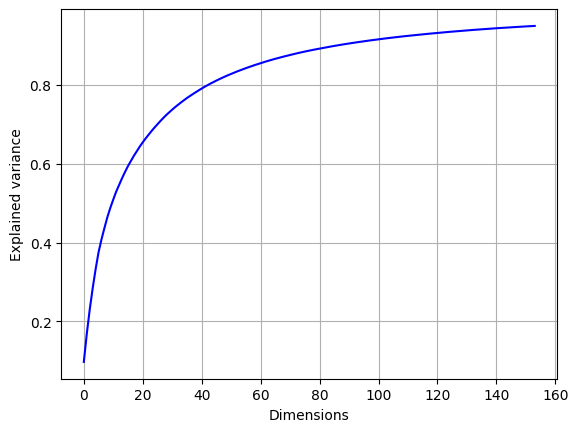

In [26]:
cumsum_inc_pca = np.cumsum(inc_pca.explained_variance_ratio_)

fig, ax = plt.subplots()
ax.plot([i for i in range(len(cumsum_inc_pca))], cumsum_inc_pca, color="blue")
ax.set_xlabel("Dimensions")
ax.set_ylabel("Explained variance")
plt.grid(True)
plt.show()

## Random Projections

In [10]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim
import numpy as np

rng = np.random.default_rng(seed=42)
m, n = 1000, 5000 # solo usar si m=n_samples < n=original_dim
X = rng.standard_normal((m,n)) # fake dataset

e = 0.2 # 20% de grado de distorción
d = johnson_lindenstrauss_min_dim(m, eps=e)
print(d)

# each item is sampled randomly from a Gaussian distribution with mean 0 and variance 1/d
P = rng.standard_normal((d, n)) / np.sqrt(d) # std_dev = sqrt(variance)
X_reduced = X @ P.T

print(X_reduced.shape)

from sklearn.random_projection import GaussianRandomProjection

gaussian_rnd_proj = GaussianRandomProjection(eps=e, random_state=42)
X_reduced2 = gaussian_rnd_proj.fit_transform(X) # same result as above

print(X_reduced2.shape)

1594
(1000, 1594)
(1000, 1594)


In [11]:
print(gaussian_rnd_proj.components_.shape)
print(gaussian_rnd_proj.n_components_)
print(gaussian_rnd_proj.eps)

(1594, 5000)
1594
0.2


In [12]:
components_pinv = np.linalg.pinv(gaussian_rnd_proj.components_)

X_recovered = X_reduced2 @ components_pinv.T
print(X_recovered.shape)

(1000, 5000)
